<a href="https://colab.research.google.com/github/Faisalt28/Rekomendasi-Film/blob/main/RekomendasiFilm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sumber Dataset
https://www.kaggle.com/datasets/amanbarthwal/imdb-movies-data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Data Understanding

In [ ]:
df = pd.read_csv("imdb-movies-dataset.csv")
#Munculkan 5 data pertama
df.head()

,Poster,Title,Year,Certificate,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,R,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,PG-13,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,PG-13,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,PG-13,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,R,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...


In [ ]:
print("Jumlah baris dan kolom:", df.shape)
print("\nKolom yang tersedia:\n", df.columns)

Jumlah baris dan kolom: (10000, 15)

Kolom yang tersedia:
 Index(['Poster', 'Title', 'Year', 'Certificate', 'Duration (min)', 'Genre',
       'Rating', 'Metascore', 'Director', 'Cast', 'Votes', 'Description',
       'Review Count', 'Review Title', 'Review'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Poster          10000 non-null  object 
 1   Title           10000 non-null  object 
 2   Year            9850 non-null   float64
 3   Certificate     7370 non-null   object 
 4   Duration (min)  9664 non-null   float64
 5   Genre           9993 non-null   object 
 6   Rating          9596 non-null   float64
 7   Metascore       7555 non-null   float64
 8   Director        9995 non-null   object 
 9   Cast            9961 non-null   object 
 10  Votes           9596 non-null   object 
 11  Description     10000 non-null  object 
 12  Review Count    9999 non-null   object 
 13  Review Title    9483 non-null   object 
 14  Review          9484 non-null   object 
dtypes: float64(4), object(11)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
Poster,0
Title,0
Year,150
Certificate,2630
Duration (min),336
Genre,7
Rating,404
Metascore,2445
Director,5
Cast,39


In [ ]:
print("Statistik numerik")
print(df.describe())

print("\nStatistik untuk kolom kategorikal (contoh: Genre)")
print(df['Genre'].value_counts().head(10))

Statistik numerik
              Year  Duration (min)       Rating    Metascore
count  9850.000000     9664.000000  9596.000000  7555.000000
mean   2005.761421      108.809603     6.438610    58.068299
std      18.958005       23.159749     1.051412    17.845240
min    1929.000000       45.000000     1.300000     1.000000
25%    1997.000000       95.000000     5.800000    45.500000
50%    2012.000000      105.000000     6.500000    58.000000
75%    2021.000000      118.000000     7.200000    71.000000
max    2025.000000      746.000000     9.700000   100.000000

Statistik untuk kolom kategorikal (contoh: Genre)
Genre
Drama                           504
Comedy, Drama, Romance          368
Drama, Romance                  360
Comedy                          302
Comedy, Drama                   292
Comedy, Romance                 241
Action, Crime, Drama            236
Animation, Adventure, Comedy    220
Action, Adventure, Comedy       194
Crime, Drama, Mystery           178
Name: count, dty

In [ ]:
print("Contoh nilai Genre")
print(df['Genre'].unique()[:10])

print("\nContoh Description")
print(df['Description'].iloc[:10])

Contoh nilai Genre
['Comedy, Drama, Romance' 'Action, Adventure, Sci-Fi'
 'Biography, Comedy, History' 'Action, Comedy, Drama'
 'Drama, Romance, Sport' 'Horror, Thriller' 'Action, Adventure, Thriller'
 'Comedy, Romance' 'Action, Drama, War' 'Action, Adventure, Drama']

Contoh Description
0    Solène, a 40-year-old single mom, begins an un...
1    Many years after the reign of Caesar, a young ...
2    In 1963 Michigan, business rivals Kellogg's an...
3    A down-and-out stuntman must find the missing ...
4    Tashi, a former tennis prodigy turned coach, t...
5    After a group of criminals kidnap the ballerin...
6    A journey across a dystopian future America, f...
7    An update to the 1996 film 'Twister', which ce...
8    After an amazing first date, Bea and Ben's fie...
9    The British military recruits a small group of...
Name: Description, dtype: object


1. Distribusi IMDb Rating


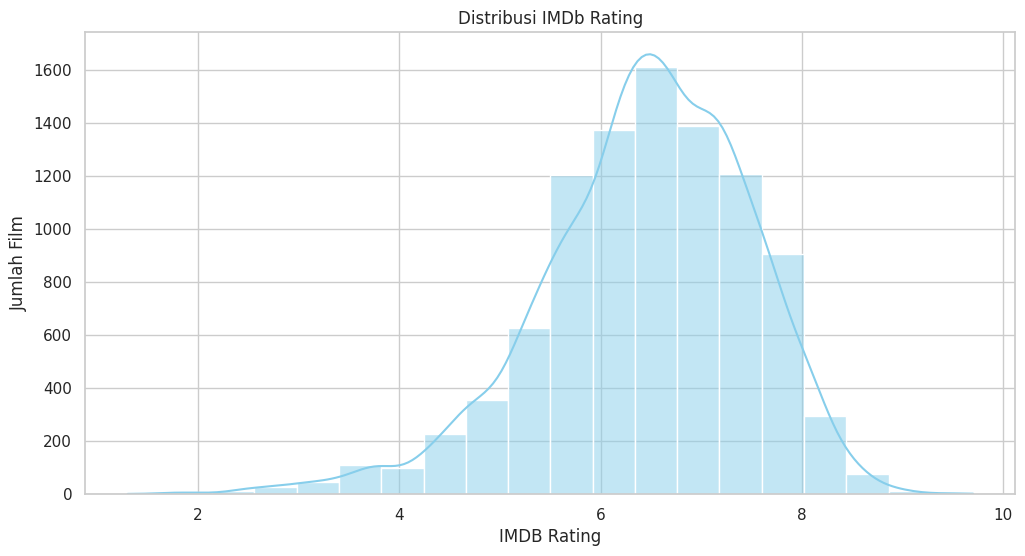


2. Distribusi Genre


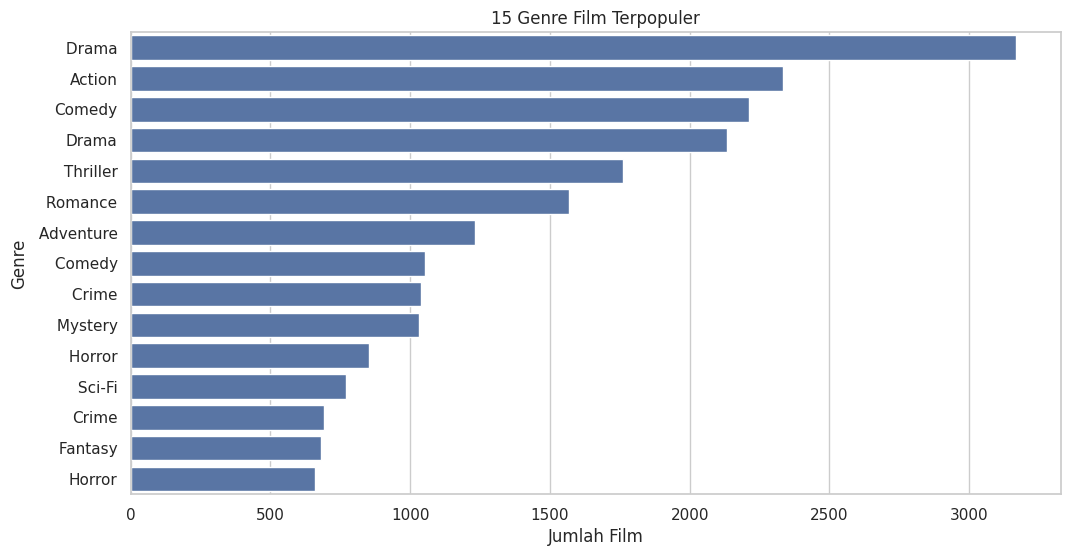


3. Jumlah Film per Tahun


/tmp/ipython-input-12-2770079593.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=df.sort_values('Year'), palette='magma')


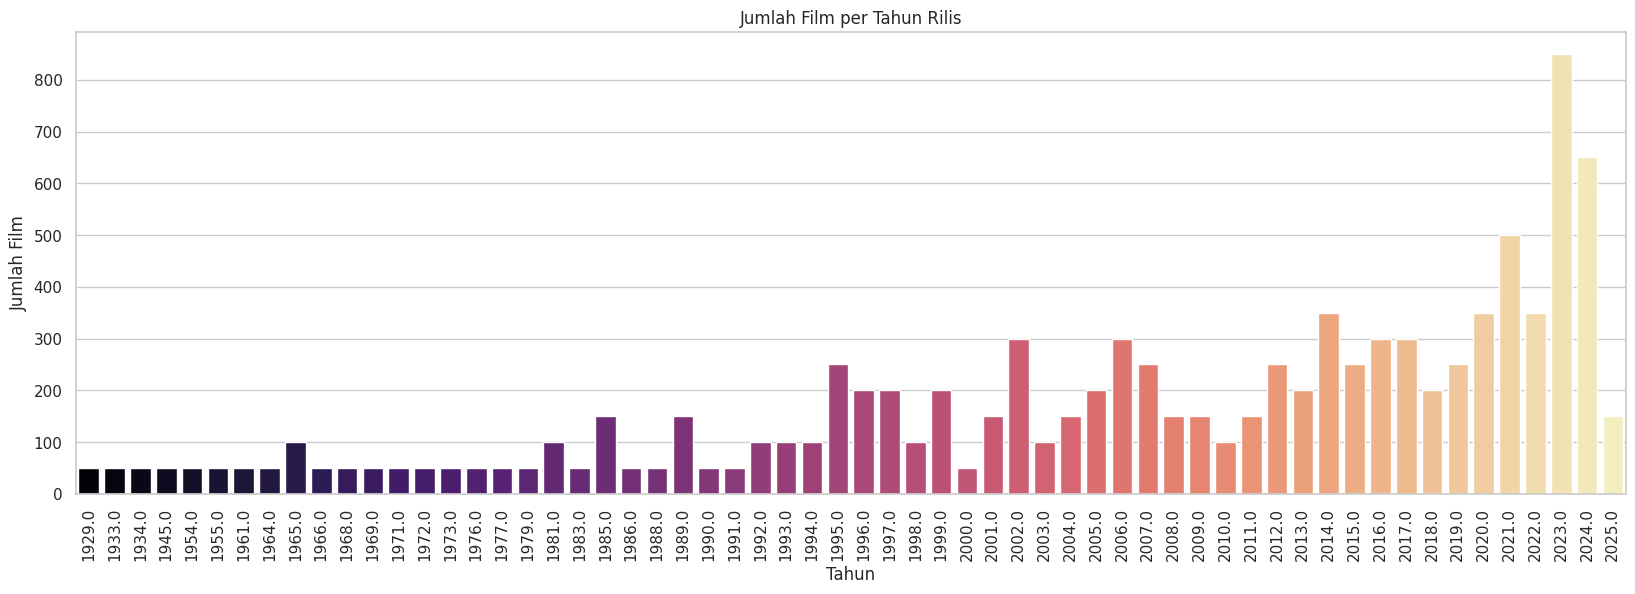

In [ ]:
#Visualisasi Dataset

sns.set(style="whitegrid")

print("1. Distribusi IMDb Rating")
plt.figure(figsize=(12, 6))
sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi IMDb Rating')
plt.xlabel('IMDB Rating')
plt.ylabel('Jumlah Film')
plt.show()

print("\n2. Distribusi Genre")
plt.figure(figsize=(12, 6))
genre_list = df['Genre'].str.split(',').explode()
top_genres = genre_list.value_counts().head(15)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('15 Genre Film Terpopuler')
plt.xlabel('Jumlah Film')
plt.ylabel('Genre')
plt.show()

print("\n3. Jumlah Film per Tahun")
plt.figure(figsize=(20, 6))
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
sns.countplot(x='Year', data=df.sort_values('Year'), palette='magma')
plt.xticks(rotation=90)
plt.title('Jumlah Film per Tahun Rilis')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Film')
plt.show()

# Data preparation

In [ ]:
#Hapus data dengan genre yang kosong
# Hapus baris yang kolom Genre-nya kosong atau NaN
df = df[df['Genre'].notna() & (df['Genre'].str.strip() != '')]

# Reset index setelah drop
df = df.reset_index(drop=True)

# Cek apakah masih ada genre kosong
print("Sisa baris dengan Genre kosong:", df['Genre'].isna().sum())


Sisa baris dengan Genre kosong: 0


In [ ]:
# Cek jumlah judul duplikat
print(df['Title'].duplicated().sum())

# Jika ada duplikat, hapus
df = df.drop_duplicates(subset='Title')

366


In [ ]:
#Bersihkan Whitespace
df['Title'] = df['Title'].str.strip()

In [ ]:
#Normalisasi year dan rating
# Mengisi nilai NaN pada kolom Year dengan rata-rata Year
rerataYear = df['Year'].mean()
df['Year'] = df['Year'].fillna(rerataYear)

# Mengisi nilai NaN pada kolom Rating dengan rata-rata Rating
rerataRating = df['Rating'].mean()
df['Rating'] = df['Rating'].fillna(rerataRating)

#Pengecekan
print(f"Pengecekan NaN Year = {df['Year'].isna().sum()}")
print(f"Pengecekan NaN Rating = {df['Rating'].isna().sum()}")

Pengecekan NaN Year = 0
Pengecekan NaN Rating = 0


In [ ]:
df['Year'] = df['Year'].astype(int)

In [ ]:
feature_selection = ['Title', 'Year', 'Rating', 'Genre', 'Description']
df = df[feature_selection]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9627 entries, 0 to 9992
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        9627 non-null   object 
 1   Year         9627 non-null   int64  
 2   Rating       9627 non-null   float64
 3   Genre        9627 non-null   object 
 4   Description  9627 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 451.3+ KB


In [ ]:
df.describe()

,Year,Rating
count,9627.000000,9627.000000
mean,2005.763062,6.450470
std,18.826834,1.022763
min,1929.000000,1.300000
25%,1997.000000,5.900000
50%,2011.000000,6.500000
75%,2021.000000,7.200000
max,2025.000000,9.700000


# Modelling

In [ ]:
# Gabungkan Genre, Year, dan Description menjadi satu teks
df['combined_features'] = df['Genre'] + ' ' + df['Year'].astype(str) + ' ' + df['Description']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF
tfidf = TfidfVectorizer(stop_words='english')

# Transformasi teks ke dalam TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)  # Harus (jumlah_film, jumlah_kata_unik)

TF-IDF matrix shape: (9627, 19490)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Hitung kesamaan antar anime
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [ ]:
# Pastikan index baris sesuai
df = df.reset_index(drop=True)

# Buat mapping dari judul ke index baris
indices = pd.Series(df.index, index=df['Title'])

In [ ]:
def get_top_anime_by_genre(genre_query, top_n=10):
    # Filter genre yang mengandung keyword (case-insensitive)
    filtered = df[df['Genre'].str.contains(genre_query, case=False)]

    if filtered.empty:
        return f"Tidak ditemukan anime dengan genre '{genre_query}'."

    # Urutkan berdasarkan rating
    top_anime = filtered.sort_values(by='Rating', ascending=False).head(top_n)

    return top_anime[['Title', 'Year', 'Rating', 'Genre']]

In [ ]:
def recommend_similar_anime(title, top_n=5):
    if title not in indices:
        return f"Anime '{title}' tidak ditemukan."

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    similar_indices = [i[0] for i in sim_scores]

    return df.iloc[similar_indices][['Title', 'Year', 'Rating', 'Description']]

## Hasil model

In [ ]:
get_top_anime_by_genre('Animation')

,Title,Year,Rating,Genre
194,Spider-Man: Across the Spider-Verse,2006,8.6,"Animation, Action, Adventure"
385,Sen to Chihiro no kamikakushi,2023,8.6,"Animation, Adventure, Family"
1286,Hotaru no haka,2017,8.5,"Animation, Drama, War"
365,The Lion King,2023,8.5,"Animation, Adventure, Drama"
668,Spider-Man: Into the Spider-Verse,2012,8.4,"Animation, Action, Adventure"
901,WALL·E,1990,8.4,"Animation, Adventure, Family"
696,Kimi no na wa.,1996,8.4,"Animation, Drama, Fantasy"
704,Coco,1996,8.4,"Animation, Adventure, Drama"
758,Toy Story,2005,8.3,"Animation, Adventure, Comedy"
1225,Mononoke-hime,2016,8.3,"Animation, Action, Adventure"


In [ ]:
recommend_similar_anime('Hotaru no haka')

,Title,Year,Rating,Description
460,Empire of the Sun,1985,7.7,A young English boy struggles to survive under...
5465,Mudbound,1995,7.4,Two men return home from World War II to work ...
8696,Little Boy,2006,7.3,An eight-year-old boy is willing to do whateve...
8991,The Power of One,2014,7.1,"An English boy, living in Africa during World ..."
8532,The Big Red One,2024,7.1,A hardened sergeant and the four core members ...


In [ ]:
# Simpan model
with open('rekomendasi_film.pkl', 'wb') as f:
    pickle.dump((df, cosine_sim, indices), f)
